# EPI DTI, part 1 — build the scan, and the field map it needs

The **same diffusion encoding** as `dti_spiral/`, read out by a ramp-sampled EPI train instead of a
spiral. Only the readout changes, which is the point of having both: the diffusivities have to agree,
and where they do not, that is the readout's error budget.

Three things about EPI drive every choice below.

**Off-resonance displaces rather than blurs.** The phase a voxel accrues between successive lines is
`2π·df·echo_spacing`, which is linear in `ky` — and a linear phase in k-space is a *shift* in image
space. `readout.pe_bandwidth_per_pixel_hz` is the conversion, and it is the number to know about an
EPI protocol.

**The echo spacing is slew-limited, not amplitude-limited.** For a lobe of fixed area the
minimum-time trapezoid is a triangle at `G = √(A·S)`, which here is 49 mT/m against a 170 mT/m limit.
So the amplitude limit never binds, there is no flat top at all, and **every sample is on a ramp** —
which makes the trajectory non-uniform in `kx` and the reconstruction a gridding problem.

**A train that oscillates at 1 kHz for 50 ms is the peripheral-nerve worst case.** That is the
opposite of the spiral, where derating the readout did nothing for PNS. Section 5 measures it.

In [1]:
%matplotlib inline
import itertools
import math
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pypulseq as pp

import seqcraft as sc

print('seqcraft', sc.__version__)

D:\MIniconda\envs\NUM\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


D:\MIniconda\envs\NUM\Lib\site-packages\sigpy\config.py:27: UserWarning: Importing cupy.cuda.cudnn failed. For more details, see the error stack below:
DLL load failed while importing cudnn: The specified module could not be found.
  warnings.warn(


seqcraft 0.3.0


## 1. Everything you would change

The diffusion half is copied from `dti_spiral/01_build.ipynb` unchanged, deliberately: two readouts,
one encoding.

In [2]:
# ---- scanner ------------------------------------------------------------------------------
SCANNER     = 'cima_x'
GRAD_DERATE = 0.85       # fraction of peak gradient
# Two slew limits, because the diffusion lobes and the readout want opposite things.  The lobes are
# derated for PNS on a face-diagonal direction, as in the spiral notebook.  The *readout* runs at
# full slew here, because echo spacing scales as 1/sqrt(slew) and every microsecond of it is paid
# for twice -- once in TE and once in distortion.  Section 5 measures what that costs in PNS and
# prints the whole trade, because the answer belongs to your hardware and not to this notebook.
SLEW_DIFFUSION = 0.30
SLEW_READOUT   = 1.00
REGIME      = 'epi'          # the readout, the pulses and the spoilers
DIFF_REGIME = 'diffusion'

# ---- geometry, shared with the spiral example so the two are comparable -------------------
FOV_MM       = 240.0
SLICE_MM     = 4.0
SLICE_POS_MM = 0.0
MATRIX       = 128       # 1.88 mm in plane, as the spiral

# ---- the EPI readout ----------------------------------------------------------------------
PARTIAL_FOURIER_PE = 0.75    # truncates the LOW end of ky, which is what buys TE
PARTIAL_ECHO       = 1.00    # the same lever along the readout; 1.0 is symmetric
SHOT_COUNTS        = (1, 2)  # single-shot and two-shot, built side by side
# adc_dwell_ns=None lets the module take the longest dwell Nyquist allows at the lobe's peak, which
# is the binding constraint when sampling the ramps.  A finer dwell buys nothing and costs samples.
ADC_DWELL_NS       = None

# ---- the diffusion encoding, identical to the spiral example ------------------------------
B_VALUE   = 1000.0       # s/mm^2
MAX_B1_UT = 13.0
TR_S      = 2.0          # per spin echo, so eddy currents decay before the next one
EXC_US    = 2000.0
REFOC_US  = 6000.0
FAT_SAT   = True

# ---- the field map ------------------------------------------------------------------------
# Duplicated from the spiral example on purpose: each folder runs on its own, and this copy is
# parameterised to *this* matrix.  Matching the grids is what removes the resampling step, and
# resampling a B0 map at a non-integer ratio is a moire generator rather than a smooth error.
B0_MATRIX   = MATRIX
B0_FLIP_DEG = 15.0
B0_TE1_MS   = 4.0
B0_TR_MS    = 25.0
B0_DUMMIES  = 60

system = (sc.System.preset(SCANNER)
          .derate(REGIME, grad=GRAD_DERATE, slew=SLEW_READOUT)
          .derate(DIFF_REGIME, grad=GRAD_DERATE, slew=SLEW_DIFFUSION))
system = system.with_max_b1(MAX_B1_UT)
raster = system.block_raster
ADC_LIMIT = system.limits(REGIME).adc_samples_limit

print(f'FOV {FOV_MM:.0f} mm, slice {SLICE_MM:.1f} mm at {SLICE_POS_MM:+.0f} mm')
print(f'EPI  {MATRIX}x{MATRIX} -> {FOV_MM / MATRIX:.2f} mm, partial Fourier '
      f'{PARTIAL_FOURIER_PE:.2f}, shots {SHOT_COUNTS}')
print(f'readout slew {SLEW_READOUT:.2f} x, diffusion slew {SLEW_DIFFUSION:.2f} x of '
      f'{system.convert(system.default.max_slew, "Hz/m/s", "T/m/s"):.0f} T/m/s')
print(f'peak B1 limit {MAX_B1_UT:.1f} uT, ADC limit {ADC_LIMIT} samples per event')

FOV 240 mm, slice 4.0 mm at +0 mm
EPI  128x128 -> 1.88 mm, partial Fourier 0.75, shots (1, 2)
readout slew 1.00 x, diffusion slew 0.30 x of 200 T/m/s
peak B1 limit 13.0 uT, ADC limit 8192 samples per event


## 2. Diffusion directions

The same six signed axes plus twelve face diagonals as the spiral example — condition number √2,
better than a repulsion-optimised set of the same size. The six axes *alone* cannot fit a tensor at
all: along an axis the three off-diagonal rows are zero, so the design matrix is singular even though
the directions look ideally separated.

In [3]:
HALF = math.sqrt(2.0) / 2.0
AXES = tuple(tuple(sign if axis == index else 0.0 for axis in range(3))
             for index in range(3) for sign in (1.0, -1.0))
FACE_DIAGONALS = tuple(
    tuple(HALF * dict(zip(pair, signs)).get(axis, 0.0) for axis in range(3))
    for pair in itertools.combinations(range(3), 2)
    for signs in itertools.product((1.0, -1.0), repeat=2)
)
directions = AXES + FACE_DIAGONALS

print(f'{len(AXES)} axes + {len(FACE_DIAGONALS)} face diagonals = {len(directions)} directions')
print(f'design-matrix condition number {sc.modules.direction_condition_number(directions):.4f}'
      f'   (axes alone: {sc.modules.direction_condition_number(AXES)})')

6 axes + 12 face diagonals = 18 directions
design-matrix condition number 1.4142   (axes alone: inf)


## 3. The readouts, single-shot and two-shot

One `EPIReadout` per shot count. Everything else about the two is identical, so the printed table is
the trade the segmented variant exists to make: fewer echoes per shot means less distortion and a
shorter TE, paid for with more shots.

`prephase=True` here, so the readout owns the winders that put `k` at the corner of its own k-space.
The alternative — `prephase=False` and `prephaser_block()` placed by hand — is what you want when the
winders should share a block with the slice rewinder, and it is exercised in the getting-started
notebook.

In [4]:
readouts = {
    n: sc.modules.EPIReadout(
        system, fov_ro_mm=FOV_MM, matrix_ro=MATRIX, fov_pe_mm=FOV_MM, matrix_pe=MATRIX,
        n_shots=n, partial_fourier_pe=PARTIAL_FOURIER_PE, partial_echo=PARTIAL_ECHO,
        adc_dwell_ns=ADC_DWELL_NS, regime=REGIME)
    for n in SHOT_COUNTS
}

header = f'{"shots":>6} {"echoes":>7} {"dES/us":>7} {"train/ms":>9} {"echo@":>6} {"PE Hz/px":>9}'
header += f' {"px per 100Hz":>13} {"samples":>8} {"dwell/ns":>9} {"blip/us":>8}'
print(header)
for n, ro in readouts.items():
    print(f'{n:>6} {ro.n_echoes:>7} {ro.echo_spacing * 1e6:>7.0f} '
          f'{ro.train_duration * 1e3:>9.2f} {ro.echo_index:>6} '
          f'{ro.pe_bandwidth_per_pixel_hz:>9.2f} '
          f'{100.0 / ro.pe_bandwidth_per_pixel_hz:>13.2f} '
          f'{ro.n_samples:>8} {ro.dwell_s * 1e9:>9.0f} {ro.blip_duration * 1e6:>8.0f}')

one = readouts[1]
print()
print(f'the lobe is a pure triangle: ramp {one.ramp_time * 1e6:.0f} us, flat '
      f'{one.flat_time * 1e6:.0f} us, peak '
      f'{system.convert(one.peak_amplitude_Hz_per_m, "Hz/m", "mT/m"):.2f} mT/m against a '
      f'{system.convert(float(one.opts.max_grad), "Hz/m", "mT/m"):.0f} mT/m limit')
print(f'  so the *slew* limit binds, not the amplitude limit, and there is nothing to sample but '
      f'ramps')
print(f'blip floors: ' + ', '.join(f'{k} {v * 1e6:.0f} us' for k, v in one.blip_floors.items())
      + f'  -> {one.blip_duration * 1e6:.0f} us')
print(f'sampling starts {one.sample_offset * 1e6:.0f} us into each lobe, which is >= blip/2 = '
      f'{one.blip_duration / 2 * 1e6:.0f} us -- so ky is constant while a line is read')

 shots  echoes  dES/us  train/ms  echo@  PE Hz/px  px per 100Hz  samples  dwell/ns  blip/us
     1      96     520     49.92     32     20.03          4.99    21888      2000       60
     2      48     520     24.96     16     40.06          2.50    10560      1900       80

the lobe is a pure triangle: ramp 260 us, flat 0 us, peak 48.92 mT/m against a 170 mT/m limit
  so the *slew* limit binds, not the amplitude limit, and there is nothing to sample but ramps
blip floors: slew 60 us, amplitude 20 us, adc_dead_time 20 us  -> 60 us
sampling starts 32 us into each lobe, which is >= blip/2 = 30 us -- so ky is constant while a line is read


## 4. The scans

The placement is the spiral notebook's, line for line, with `readout.time_to_echo` doing the work.
For a spiral that property is the ADC delay, because a spiral starts at k=0; here it points **17 ms
into a 50 ms train**, at the echo whose `ky` is zero. Taking the train's midpoint instead would put
TE 7.7 ms late, and nothing else in the sequence would look wrong.

In [5]:
exc = sc.modules.SLRExcitation(
    system, flip_deg=90, duration_us=EXC_US, slice_thickness_mm=SLICE_MM,
    rephase=True, regime=REGIME)
refoc = sc.modules.SLRRefocusing(
    system, flip_deg=180, duration_us=REFOC_US, slice_thickness_mm=SLICE_MM,
    crusher_twists=4, crusher_voxel_mm=SLICE_MM, regime=REGIME)
spoiler = sc.modules.Spoiler(system, twists=4, voxel_mm=SLICE_MM, axes=('z',), regime=REGIME)
fat = sc.modules.FatSat(system, voxel_mm=SLICE_MM, spoil_axes=('z',), regime=REGIME) if FAT_SAT \
    else None

# One encoder per b-value, both sharing the larger one's lobe duration so every volume has the same
# TE.  A b=0 volume at a shorter TE would carry different T2 weighting and bias the fit.
weighted = sc.modules.MonopolarDiffusion(
    system, b_value_s_per_mm2=B_VALUE, refocus_duration_us=refoc.duration * 1e6,
    regime=DIFF_REGIME)
encoders = {
    0.0: sc.modules.MonopolarDiffusion(
        system, b_value_s_per_mm2=0.0, refocus_duration_us=refoc.duration * 1e6,
        lobe_duration_us=weighted.lobe_duration * 1e6, regime=DIFF_REGIME),
    B_VALUE: weighted,
}
delta = weighted.lobe_duration
volumes = [(0.0, (0.0, 0.0, 1.0))] + [(B_VALUE, d) for d in directions]
geometry = sc.Geometry(
    fov_mm=(FOV_MM, FOV_MM, 0.0), matrix=(MATRIX, MATRIX, 1), slice_thickness_mm=SLICE_MM,
    n_slices=1, partial_fourier_pe=PARTIAL_FOURIER_PE, n_shots=max(SHOT_COUNTS))


def build(readout, name):
    '''Compile one whole acquisition around `readout`.  Returns (compiled, te, tr, plan).'''
    first_half = raster.ceil((exc.duration - exc.isodelay) + delta + refoc.isodelay)
    second_half = raster.ceil((refoc.duration - refoc.isodelay) + delta + readout.time_to_echo)
    te = 2 * max(first_half, second_half)

    t_refoc = raster.ceil(exc.isodelay + te / 2 - refoc.isodelay)
    t_lobe1 = raster.ceil(t_refoc - delta)
    t_lobe2 = raster.ceil(t_refoc + refoc.duration)
    t_read = raster.ceil(exc.isodelay + te - readout.time_to_echo)
    prep = fat.duration if fat is not None else 0.0
    shot_s = raster.ceil(prep + t_read + readout.duration + spoiler.duration)
    tr = raster.ceil(TR_S)
    if tr < shot_s:
        raise ValueError(f'TR {TR_S * 1e3:.0f} ms cannot hold a {shot_s * 1e3:.1f} ms shot')

    # All shots of a volume before moving to the next, so a volume is never left part-sampled if the
    # scan is stopped early -- and so motion between shots corrupts one volume rather than all.
    plan = [(v, s) for v in range(len(volumes)) for s in range(readout.n_shots)]
    tree = sc.LogicBlock(name)
    for index, (volume, shot) in enumerate(plan):
        b_value, direction = volumes[volume]
        t0 = index * tr
        if fat is not None:
            tree.add(t0, fat.build())
        t = t0 + prep
        tree.add(t, exc.build(slice_offset_m=SLICE_POS_MM / 1e3))
        tree.add(t + t_lobe1, encoders[b_value].build(part='pre', direction=direction))
        tree.add(t + t_refoc, refoc.build(slice_offset_m=SLICE_POS_MM / 1e3))
        tree.add(t + t_lobe2, encoders[b_value].build(part='post', direction=direction))
        tree.add(t + t_read, readout.build(shot=shot))
        tree.add(t + t_read + readout.duration, spoiler.build())
        # SET indexes the volume; the readout emits SEG, LIN and REV itself, since it owns the table.
        tree.add(t + t_read, pp.make_label('SET', 'SET', volume))

    compiled = sc.compile(
        tree, system, geometry=geometry, regime=REGIME, name=name,
        definitions={
            'TE': te, 'TR': tr,
            'bValues': [0.0, B_VALUE],
            'AchievedbValues': [0.0, round(weighted.achieved_b_s_per_mm2(), 2)],
            'DiffusionScheme': 'monopolar',
            'DiffusionDirections': len(directions),
            'DiffusionLobeDuration': weighted.lobe_duration,
            'DiffusionBigDelta': weighted.big_delta,
            'FatSaturation': 1 if fat is not None else 0,
            **readout.definitions(),
        },
    )
    compiled.check().raise_if_failed()
    return compiled, te, tr, plan


scans = {}
for n, ro in readouts.items():
    compiled, te, tr, plan = build(ro, f'epi_dwi_{n}shot')
    scans[n] = {'compiled': compiled, 'te': te, 'tr': tr, 'plan': plan, 'readout': ro}
    print(f'{n} shot: {compiled.n_blocks:5d} blocks, TE {te * 1e3:6.2f} ms, '
          f'{len(plan)} shots x {tr:.1f} s = {compiled.duration_s / 60:5.2f} min, '
          f'{len(compiled.check().warnings)} warnings')

print()
print(f'b achieved {weighted.achieved_b_s_per_mm2():.1f} s/mm2 at '
      f'{system.convert(weighted.amplitude_Hz_per_m, "Hz/m", "mT/m"):.0f} mT/m, '
      f'delta {delta * 1e3:.2f} ms, Delta {weighted.big_delta * 1e3:.2f} ms')
print(f'refocusing peaks at {refoc.peak_b1_uT:.2f} uT (limit {MAX_B1_UT:.1f}), '
      f'excitation {exc.peak_b1_uT:.2f} uT')
print(f'TE is set by the readout: {readouts[1].time_to_echo * 1e3:.2f} ms of the 1-shot TE is the '
      f'train before its own echo, against {readouts[2].time_to_echo * 1e3:.2f} ms for 2 shots')

D:\MIniconda\envs\NUM\Lib\site-packages\pypulseq\make_slr_pulse.py:66: UserWarning: Specified RF delay 0.00 us is less than the dead time 100 us. Delay was increased to the dead time.
  result = sigpy_n_seq(


E:\MGH\SeqCraft\src\seqcraft\modules\rf\pulses.py:1005: UserWarning: Specified RF delay 0.00 us is less than the dead time 100 us. Delay was increased to the dead time.
  return pp.make_gauss_pulse(**common, return_gz=False), None, None


1 shot:  2069 blocks, TE  59.40 ms, 19 shots x 2.0 s =  0.60 min, 19 warnings


2 shot:  2315 blocks, TE  42.80 ms, 38 shots x 2.0 s =  1.23 min, 38 warnings

b achieved 1000.0 s/mm2 at 170 mT/m, delta 8.71 ms, Delta 16.24 ms
refocusing peaks at 10.29 uT (limit 13.0), excitation 12.24 uT
TE is set by the readout: 17.26 ms of the 1-shot TE is the train before its own echo, against 8.96 ms for 2 shots


## 5. What the aggressive readout costs in PNS

A readout gradient reversing every 520 µs for 50 ms is close to the worst waveform there is for
peripheral nerve stimulation. Unlike the spiral, derating the readout is what moves the number — but
the table below shows it does not account for all of it: even at 0.30× the readout slew the figure
stays well above the limit, because the diffusion lobes on a face-diagonal direction put the whole
gradient vector on two axes and set a floor of their own.

The synthetic model is not a verdict — on the spiral sequence it reported 2.44× the limit where the
real Cima.X descriptor reported **0.95×**. Point `SEQCRAFT_ASC_DIR` at your own vendor descriptor and
this cell reports that instead. The `.asc` is never copied into the repository; only its name and
sha256 are recorded.

In [6]:
try:
    hardware = sc.load_hardware()
    HARDWARE_IS_REAL = True
except Exception as err:              # noqa: BLE001 - any resolution failure means "not available"
    hardware = sc.synthetic_hardware()
    HARDWARE_IS_REAL = False
    print(f'no vendor descriptor ({type(err).__name__}); using the synthetic model')
print(f'hardware: {getattr(hardware, "name", "synthetic")}'
      f'{"" if HARDWARE_IS_REAL else "  -- NOT valid for clearing a human scan"}')
print()

print(f'{"slew x":>7} {"dES/us":>7} {"train/ms":>9} {"TE/ms":>7} {"PE Hz/px":>9} {"PNS":>6}')
for slew in (1.00, 0.70, 0.55, 0.40, 0.30):
    probe_system = (sc.System.preset(SCANNER)
                    .derate(REGIME, grad=GRAD_DERATE, slew=slew)
                    .derate(DIFF_REGIME, grad=GRAD_DERATE, slew=SLEW_DIFFUSION)
                    .with_max_b1(MAX_B1_UT))
    probe_ro = sc.modules.EPIReadout(
        probe_system, fov_ro_mm=FOV_MM, matrix_ro=MATRIX, fov_pe_mm=FOV_MM, matrix_pe=MATRIX,
        n_shots=1, partial_fourier_pe=PARTIAL_FOURIER_PE, partial_echo=PARTIAL_ECHO,
        regime=REGIME)
    # One shot is enough: PNS is a property of the waveform, not of how many times it is played.
    probe_exc = sc.modules.SLRExcitation(
        probe_system, flip_deg=90, duration_us=EXC_US, slice_thickness_mm=SLICE_MM,
        rephase=True, regime=REGIME)
    probe_refoc = sc.modules.SLRRefocusing(
        probe_system, flip_deg=180, duration_us=REFOC_US, slice_thickness_mm=SLICE_MM,
        crusher_twists=4, crusher_voxel_mm=SLICE_MM, regime=REGIME)
    probe_diff = sc.modules.MonopolarDiffusion(
        probe_system, b_value_s_per_mm2=B_VALUE,
        refocus_duration_us=probe_refoc.duration * 1e6, regime=DIFF_REGIME)
    d = probe_diff.lobe_duration
    half_a = raster.ceil((probe_exc.duration - probe_exc.isodelay) + d + probe_refoc.isodelay)
    half_b = raster.ceil((probe_refoc.duration - probe_refoc.isodelay) + d
                         + probe_ro.time_to_echo)
    probe_te = 2 * max(half_a, half_b)
    t_ref = raster.ceil(probe_exc.isodelay + probe_te / 2 - probe_refoc.isodelay)
    tree = sc.LogicBlock('pns_probe')
    tree.add(0.0, probe_exc.build())
    tree.add(raster.ceil(t_ref - d), probe_diff.build(part='pre', direction=(HALF, HALF, 0.0)))
    tree.add(t_ref, probe_refoc.build())
    tree.add(raster.ceil(t_ref + probe_refoc.duration),
             probe_diff.build(part='post', direction=(HALF, HALF, 0.0)))
    tree.add(raster.ceil(probe_exc.isodelay + probe_te - probe_ro.time_to_echo), probe_ro.build())
    probe = sc.compile(tree, probe_system, regime=REGIME, name='pns_probe')
    peak = probe.pns(hardware).values['peak_pns_fraction']
    mark = '  <- built above' if abs(slew - SLEW_READOUT) < 1e-9 else ''
    print(f'{slew:>7.2f} {probe_ro.echo_spacing * 1e6:>7.0f} '
          f'{probe_ro.train_duration * 1e3:>9.2f} {probe_te * 1e3:>7.2f} '
          f'{probe_ro.pe_bandwidth_per_pixel_hz:>9.2f} {peak * 100:>5.0f}%{mark}')

print()
print('Echo spacing scales as 1/sqrt(slew), so halving the slew costs 40 % more train, 40 % more')
print('distortion and a longer TE.  The readout dominates but does not account for everything:')
print('the diffusion lobes on a face diagonal put the whole vector on two axes and set a floor,')
print('which is why the last row is still well above 100 %.  Derating SLEW_DIFFUSION moves that')
print('floor, at the cost of TE.  Whether any row is runnable is a hardware question and this')
print('cell cannot answer it -- only your own descriptor can.')

no vendor descriptor (TypeError); using the synthetic model
hardware: synthetic_generic  -- NOT valid for clearing a human scan

 slew x  dES/us  train/ms   TE/ms  PE Hz/px    PNS


   1.00     520     49.92   59.40     20.03   276%  <- built above


   0.70     620     59.52   66.20     16.80   242%


   0.55     700     67.20   71.70     14.88   219%


   0.40     820     78.72   79.88     12.70   197%


   0.30     940     90.24   88.10     11.08   175%

Echo spacing scales as 1/sqrt(slew), so halving the slew costs 40 % more train, 40 % more
distortion and a longer TE.  The readout dominates but does not account for everything:
the diffusion lobes on a face diagonal put the whole vector on two axes and set a floor,
which is why the last row is still well above 100 %.  Derating SLEW_DIFFUSION moves that
floor, at the cost of TE.  Whether any row is runnable is a hardware question and this
cell cannot answer it -- only your own descriptor can.


## 6. The field map

A spiral needs a field map because it blurs; EPI needs one because it *shifts*, and by five pixels
per 100 Hz. The same dual-echo GRE as the spiral example, at this matrix.

Five things it has to get right, each of which produced a wrong map first: the echo spacing set to
`1/(fat–water offset)` so fat cannot corrupt the phase difference; a **flyback** rather than a
reversed gradient, so both echoes land on the same k grid; the flyback area read off the gradient
*event* rather than taken as `2·k_max`; the receiver phase equal to the transmit phase; and enough
dummy excitations that the first line does not carry twice the signal of the last.

In [7]:
b0_geometry = sc.Geometry(fov_mm=(FOV_MM, FOV_MM, SLICE_MM), matrix=(B0_MATRIX, B0_MATRIX, 1),
                          slice_thickness_mm=SLICE_MM, n_slices=1)
b0_exc = sc.modules.SincExcitation(
    system, flip_deg=B0_FLIP_DEG, duration_us=1500, slice_thickness_mm=SLICE_MM,
    rephase=False, regime=REGIME)
FAT_WATER_HZ = 3.4e-6 * system.gamma * system.b0_T
WANTED_DTE = 1.0 / FAT_WATER_HZ


def b0_readout(microseconds):
    '''A readout, and the flyback that returns k exactly to where the readout started.'''
    line = sc.modules.CartesianLine(
        system, fov_ro_mm=FOV_MM, matrix_ro=B0_MATRIX, readout_duration_us=microseconds,
        prephase=False, regime=REGIME)
    # Minus the gradient's *own* area, read off the event.  Not -2 k_max: the ADC samples the flat
    # top only, so the ramps add area the sampled span never shows.  A k offset between the echoes is
    # a linear phase ramp, which over 2 pi dTE becomes an apparent field gradient of 1/dTE across the
    # FOV -- the entire unambiguous range, from an error of a few percent in one area.
    flyback = sc.modules.Prephaser(
        system, area_per_m=-float(line.gx.area), axis='x', regime=REGIME)
    return line, flyback


b0_line, b0_flyback = min(
    (b0_readout(us) for us in range(1000, 2600, 20)),
    key=lambda pair: abs(pair[0].duration + pair[1].duration - WANTED_DTE),
)
B0_DTE = raster.ceil(b0_line.duration + b0_flyback.duration)
B0_TE_S = (B0_TE1_MS / 1e3, B0_TE1_MS / 1e3 + B0_DTE)
b0_encode = sc.modules.PhaseEncode(
    system, fov_pe_mm=FOV_MM, matrix_pe=B0_MATRIX, regime=REGIME)
b0_spoil = sc.modules.Spoiler(system, twists=4, voxel_mm=SLICE_MM, axes=('z',), regime=REGIME)

t_winders = raster.ceil(b0_exc.duration)
b0_tr = raster.ceil(sc.convert(B0_TR_MS, 'ms', 's'))
t_echo1 = raster.ceil(b0_exc.isodelay + B0_TE_S[0] - b0_line.time_to_echo)
t_echo2 = raster.ceil(t_echo1 + B0_DTE)
t_spoil = raster.ceil(t_echo2 + b0_line.duration)
if t_echo1 < t_winders:
    raise ValueError('TE1 is too short for the winders')
if b0_tr < t_spoil + b0_spoil.duration:
    raise ValueError('TR cannot hold both echoes')

b0 = sc.LogicBlock('b0map')
index = 0


def b0_shot(start, signed_line, *, acquire):
    '''One TR: excitation, winders, two echoes read the same way, spoiler.'''
    phase = sc.rf_spoil_phase(index)
    b0.add(start, b0_exc.build(slice_offset_m=SLICE_POS_MM / 1e3, rf_phase_rad=phase))
    b0.add(start + t_winders, b0_exc.rephaser())
    if acquire:
        b0.add(start + t_winders, b0_encode.build(line=signed_line))
        b0.add(start + t_winders, b0_line.prephaser_block())
        b0.add(start + t_echo1, b0_line.build(polarity=1, rf_phase_rad=phase))
        b0.add(start + t_echo1 + b0_line.duration, b0_flyback.build())
        b0.add(start + t_echo2, b0_line.build(polarity=1, rf_phase_rad=phase))
        # ECO as well as LIN: without it two ADCs claim the same k-space address, and `check()` says
        # so rather than leaving it to be discovered in the reconstruction.
        line_label = signed_line + b0_geometry.kspace_center_line
        b0.add(start + t_echo1, pp.make_label('LIN', 'SET', line_label),
               pp.make_label('ECO', 'SET', 0))
        b0.add(start + t_echo2, pp.make_label('LIN', 'SET', line_label),
               pp.make_label('ECO', 'SET', 1))
    b0.add(start + t_spoil, b0_spoil.build())


for _ in range(B0_DUMMIES):
    b0_shot(index * b0_tr, 0, acquire=False)
    index += 1
for line in b0_geometry.pe_lines:
    b0_shot(index * b0_tr, line - b0_geometry.kspace_center_line, acquire=True)
    index += 1

b0 = sc.compile(
    b0, system, geometry=b0_geometry, regime=REGIME, name='b0map',
    definitions={'TE': list(B0_TE_S), 'TR': b0_tr, 'FlipAngle': B0_FLIP_DEG,
                 'EchoSpacing': B0_DTE, **b0_line.definitions()},
)
b0.check().raise_if_failed()
print(b0)
print(f'{B0_DUMMIES} dummies + {B0_MATRIX} lines, two echoes per TR = {index} shots, '
      f'{b0.duration_s:.1f} s')
print(f'  echo spacing {B0_DTE * 1e3:.3f} ms (wanted {WANTED_DTE * 1e3:.3f} to put fat in phase), '
      f'unambiguous to +-{1 / (2 * B0_DTE):.0f} Hz')
print(f'  and +-{1 / (2 * B0_DTE) / readouts[1].pe_bandwidth_per_pixel_hz:.1f} pixels of EPI '
      f'displacement, which is the range the map has to cover')

E:\MGH\SeqCraft\src\seqcraft\modules\rf\pulses.py:529: UserWarning: Specified RF delay 0.00 us is less than the dead time 100 us. Delay was increased to the dead time.
  rf, gz, gzr = pp.make_sinc_pulse(


CompiledSequence(b0map, 1323 blocks, 4.684 s, 0 errors, 128 warnings)
60 dummies + 128 lines, two echoes per TR = 188 shots, 4.7 s
  echo spacing 2.380 ms (wanted 2.387 to put fat in phase), unambiguous to +-210 Hz
  and +-10.5 pixels of EPI displacement, which is the range the map has to cover


## 7. Check the physics

Every number here is one an independent calculation gives, not one the code produced.

In [8]:
# --- b-value, against numerical integration of the built waveform -------------------------------
dt = system.grad_raster.dt
n_lobe = int(round(weighted.lobe_duration / dt))


def sampled(block):
    out = np.zeros((3, n_lobe + 2))
    for node in block.nodes:
        if getattr(node.item, 'type', None) in ('trap', 'grad'):
            times, wave = sc.events.waveform_of(node.item, dt)
            at = np.round((times + node.start) / dt).astype(int)
            keep = at < out.shape[1]
            out['xyz'.index(node.item.channel), at[keep]] += wave[keep]
    return out


gap = int(round(refoc.duration / dt))
pre = sampled(weighted.build(part='pre', direction=(1.0, 0.0, 0.0)))
post = sampled(weighted.build(part='post', direction=(1.0, 0.0, 0.0)))
# The 180 inverts accumulated phase, so the second lobe enters with the opposite sign.
effective = np.concatenate([pre, np.zeros((3, gap)), -post], axis=1)
b_numeric = (2 * np.pi) ** 2 * np.sum((np.cumsum(effective, axis=1) * dt) ** 2) * dt / 1e6
print(f'b-value      module {weighted.achieved_b_s_per_mm2():8.2f}   integrated {b_numeric:8.2f}   '
      f'({abs(b_numeric / weighted.achieved_b_s_per_mm2() - 1) * 100:.2f} %)')

# --- k at the echo, on every axis, from pypulseq's own trajectory --------------------------------
# Restricted to the FIRST shot's samples.  Over the whole file every shot has a k=0 crossing, so an
# argmin over all of them lands in whichever shot happens to pass closest -- and then the elapsed
# time is measured from the wrong excitation and reads as tens of seconds.
for n, scan in scans.items():
    ro = scan['readout']
    k = scan['compiled'].kspace()
    first_shot = slice(0, ro.n_samples)
    at_echo = int(np.argmin(np.hypot(k['k_adc'][0][first_shot], k['k_adc'][1][first_shot])))
    elapsed = float(k['t_adc'][at_echo] - k['t_excitation'][0])
    print(f'{n} shot       k at echo ' + '  '.join(
        f'k_{a} {float(k["k_adc"][i][at_echo]):+6.2f}' for i, a in enumerate('xyz'))
        + f'  1/m   at {elapsed * 1e3:.2f} ms (TE {scan["te"] * 1e3:.2f})')
print('             k_z is what catches a missing slice rewinder: without it, -525 1/m')

# --- the sampled extent is 2 k_max, and the lobe carries more than that -------------------------
ro = readouts[1]
lobe_area = ro.peak_amplitude_Hz_per_m * (ro.ramp_time + ro.flat_time)
k_one = ro.trajectory(0)
sampled_span = float(k_one[0].max() - k_one[0].min())
wanted_span = (1.0 + ro.partial_echo) * ro.k_max_ro_per_m
print()
print(f'sampled extent  {sampled_span:8.4f} 1/m   wanted {wanted_span:8.4f}   '
      f'lobe carries {lobe_area:8.4f}')
print(f'  the {lobe_area - wanted_span:.2f} 1/m difference is the two corners the ADC skips, '
      f'{(lobe_area - wanted_span) / ro.dk_pe_per_m:.2f} dk')
print(f'  a prephaser of minus k_max would displace every shot by exactly that')

# --- ky is constant while a line is read ---------------------------------------------------------
per_echo = scans[1]['compiled'].kspace()['k_adc'][1][:ro.n_samples].reshape(
    ro.n_echoes, ro.samples_per_echo)
print(f'ky drift within an echo, worst {float(np.ptp(per_echo, axis=1).max()):.6f} 1/m  '
      f'(the blip lies wholly outside every ADC window)')

# --- both dwell bounds, checked rather than assumed ---------------------------------------------
nyquist = 1.0 / ((FOV_MM / 1e3) * ro.peak_amplitude_Hz_per_m)
print(f'dwell {ro.dwell_s * 1e9:.0f} ns   Nyquist bound at the apex {nyquist * 1e9:.0f} ns   '
      f'sample spacing {ro.peak_amplitude_Hz_per_m * ro.dwell_s:.4f} of dk {ro.dk_pe_per_m:.4f}')
if ADC_LIMIT and ro.samples_per_echo > ADC_LIMIT:
    raise ValueError(f'{ro.samples_per_echo} samples per echo exceeds the {ADC_LIMIT} limit')
print(f'{ro.samples_per_echo} samples per echo, limit {ADC_LIMIT} per ADC event')

# --- the trajectory the sidecar will carry, against the compiled sequence ------------------------
for n, scan in scans.items():
    ro = scan['readout']
    theirs = scan['compiled'].kspace()['k_adc'][:2, :ro.n_samples]
    worst = float(np.abs(ro.trajectory(0) - theirs).max())
    print(f'{n} shot       sidecar agrees with the sequence to {worst:.4f} 1/m '
          f'({worst / ro.dk_pe_per_m * 100:.3f} % of dk)')

b-value      module  1000.00   integrated  1001.42   (0.14 %)


1 shot       k at echo k_x  +2.08  k_y  -0.00  k_z  -0.83  1/m   at 59.40 ms (TE 59.40)


2 shot       k at echo k_x  +2.02  k_y  -0.00  k_z  -0.83  1/m   at 42.80 ms (TE 42.80)
             k_z is what catches a missing slice rewinder: without it, -525 1/m

sampled extent  532.8126 1/m   wanted 533.3333   lobe carries 541.5365
  the 8.20 1/m difference is the two corners the ADC skips, 1.97 dk
  a prephaser of minus k_max would displace every shot by exactly that


ky drift within an echo, worst 0.000000 1/m  (the blip lies wholly outside every ADC window)
dwell 2000 ns   Nyquist bound at the apex 2000 ns   sample spacing 4.1657 of dk 4.1667
228 samples per echo, limit 8192 per ADC event


1 shot       sidecar agrees with the sequence to 0.0000 1/m (0.000 % of dk)


2 shot       sidecar agrees with the sequence to 0.0000 1/m (0.000 % of dk)


Left: the acquired k-space -- asymmetric in ky, which is partial Fourier.
Middle: no flat top at all, and the blip centred on the junction outside both ADC windows.
Right: samples are sparsest exactly where k = 0, which is the opposite of a spiral.


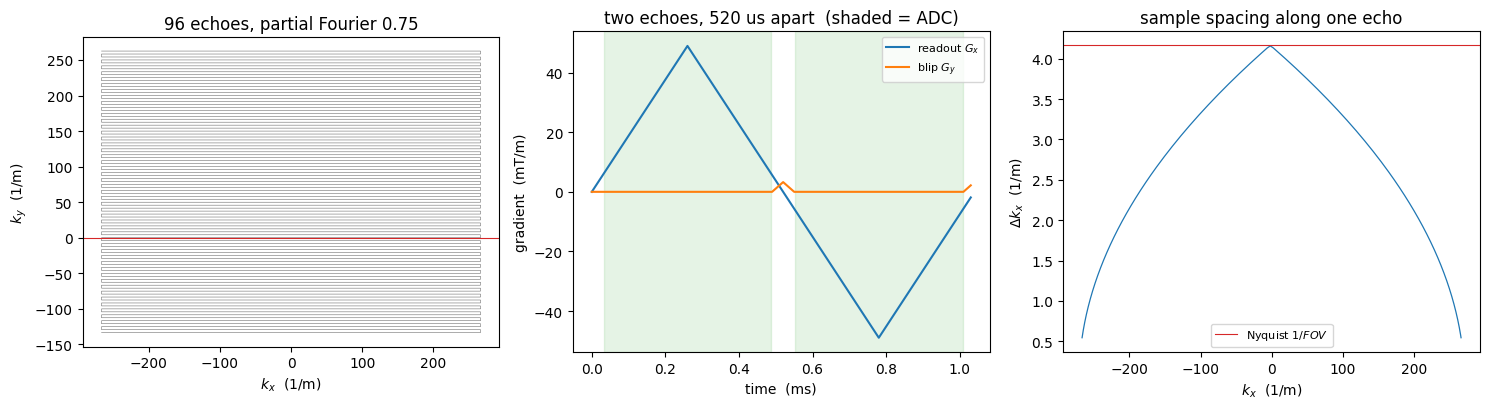

In [9]:
figure, axes = plt.subplots(1, 3, figsize=(15, 4.2))

ro = readouts[1]
k = ro.trajectory(0)
axes[0].plot(k[0], k[1], lw=0.35, color='0.35')
axes[0].set(title=f'{ro.n_echoes} echoes, partial Fourier {ro.partial_fourier_pe:.2f}',
            xlabel='$k_x$  (1/m)', ylabel='$k_y$  (1/m)')
axes[0].axhline(0.0, color='C3', lw=0.8)
axes[0].set_aspect('equal')

# Two echoes of the readout waveform, with the sampled windows shaded: the blip sits in the gap.
span = 2 * ro.echo_spacing
t = np.arange(0.0, span, system.grad_raster.dt)
gx_knots_t, gx_knots_a = sc.events.knots_of(ro._gx)
gy_knots_t, gy_knots_a = sc.events.knots_of(ro._gy)
axes[1].plot(t * 1e3, np.interp(t, gx_knots_t, gx_knots_a) / system.gamma * 1e3,
             label='readout $G_x$')
axes[1].plot(t * 1e3, np.interp(t, gy_knots_t, gy_knots_a) / system.gamma * 1e3,
             label='blip $G_y$')
for echo in range(2):
    start = echo * ro.echo_spacing + ro.sample_offset
    axes[1].axvspan(start * 1e3, (start + ro.samples_per_echo * ro.dwell_s) * 1e3,
                    color='C2', alpha=0.12)
axes[1].set(title=f'two echoes, {ro.echo_spacing * 1e6:.0f} us apart  (shaded = ADC)',
            xlabel='time  (ms)', ylabel='gradient  (mT/m)')
axes[1].legend(loc='upper right', fontsize=8)

# kx sample spacing along one echo: dense on the ramps, sparsest at k=0.  This is why the density
# compensation has to be |dk/dt| and not |k|.
one_echo = k[0][:ro.samples_per_echo]
axes[2].plot(one_echo[:-1], np.abs(np.diff(one_echo)), lw=0.9)
axes[2].axhline(ro.dk_pe_per_m, color='C3', lw=0.8, label='Nyquist $1/FOV$')
axes[2].set(title='sample spacing along one echo', xlabel='$k_x$  (1/m)',
            ylabel='$\\Delta k_x$  (1/m)')
axes[2].legend(loc='lower center', fontsize=8)

figure.tight_layout()
print('Left: the acquired k-space -- asymmetric in ky, which is partial Fourier.')
print('Middle: no flat top at all, and the blip centred on the junction outside both ADC windows.')
print('Right: samples are sparsest exactly where k = 0, which is the opposite of a spiral.')

## 8. Write the files

Two `.seq` files, a provenance sidecar for each, and a `.traj.npz` per readout carrying the
trajectory **at ADC sample times** with `t_adc_s` measured **from the echo** — negative for the first
third of the train. That reference is recorded rather than inferred: a reconstruction that took the
first sample as the echo would put `2π·df·17 ms` of spatially varying phase into the operator.

In [10]:
OUT = Path('seq')
OUT.mkdir(exist_ok=True)
for stale in OUT.glob('*'):
    stale.unlink()

for n, scan in scans.items():
    ro = scan['readout']
    stem = f'epi_dwi_{n}shot_{MATRIX}_fov{FOV_MM:.0f}_b{B_VALUE:.0f}_pf{ro.partial_fourier_pe:.2f}'
    written = scan['compiled'].write(OUT / f'{stem}.seq')

    trajectory = np.stack([ro.trajectory(shot) for shot in range(n)])
    t_adc = ro.sample_times()
    theirs = scan['compiled'].kspace()['k_adc'][:2, :ro.n_samples]
    disagreement = float(np.abs(trajectory[0] - theirs).max())
    if disagreement > 0.01 * ro.dk_pe_per_m:
        raise ValueError(f'sidecar disagrees with the sequence by {disagreement:.3f} 1/m')

    np.savez_compressed(
        OUT / f'{stem}.traj.npz',
        k_per_m=trajectory.astype(np.float32),      # (shot, xy, ADC sample), 1/m
        t_adc_s=t_adc.astype(np.float64),           # already measured from the echo
        t_echo_s=np.float64(0.0),                   # ... so the reference is zero
        fov_m=np.float64(FOV_MM / 1e3), matrix=np.int64(MATRIX),
        n_interleaves=np.int64(n),
        dwell_s=np.float64(ro.dwell_s), n_samples=np.int64(ro.n_samples),
        samples_per_echo=np.int64(ro.samples_per_echo), n_echoes=np.int64(ro.n_echoes),
        echo_index=np.int64(ro.echo_index), echo_spacing_s=np.float64(ro.echo_spacing),
        pe_bandwidth_hz=np.float64(ro.pe_bandwidth_per_pixel_hz),
        total_readout_time_s=np.float64(ro.total_readout_time_s),
        partial_fourier_pe=np.float64(ro.partial_fourier_pe),
        lines=np.asarray([ro.lines(s) for s in range(n)], dtype=np.int64),
        te_s=np.float64(scan['te']), tr_s=np.float64(scan['tr']),
        directions=np.asarray(directions, dtype=np.float32),
        b_values=np.asarray([0.0, B_VALUE], dtype=np.float64),
        achieved_b_values=np.asarray([0.0, weighted.achieved_b_s_per_mm2()], dtype=np.float64),
    )
    print(f'{written.path.name}')
    print(f'  {written.n_blocks} blocks, {written.duration_s / 60:.2f} min, '
          f'{written.path.stat().st_size / 1e6:.2f} MB, sha256 {written.sha256[:16]}...')
    print(f'  trajectory {trajectory.shape}, agrees to {disagreement:.4f} 1/m, '
          f't_adc {t_adc.min() * 1e3:+.2f} .. {t_adc.max() * 1e3:+.2f} ms about the echo')

b0_stem = f'b0map_{B0_MATRIX}_fov{FOV_MM:.0f}'
b0_written = b0.write(OUT / f'{b0_stem}.seq')
np.savez_compressed(
    OUT / f'{b0_stem}.meta.npz',
    te_s=np.asarray(B0_TE_S, dtype=np.float64),
    delta_te_s=np.float64(B0_DTE),
    fov_m=np.float64(FOV_MM / 1e3), matrix=np.int64(B0_MATRIX),
    lines=np.asarray(b0_geometry.pe_lines, dtype=np.int64),
    dummies=np.int64(B0_DUMMIES),
    polarity=np.asarray([1, 1], dtype=np.int64),      # flyback, so both echoes read the same way
    centre_line=np.int64(b0_geometry.kspace_center_line),
    n_samples=np.int64(b0_line.adc.num_samples),
)
print(f'{b0_written.path.name}')
print(f'  {b0_written.n_blocks} blocks, {b0_written.duration_s:.1f} s, '
      f'sha256 {b0_written.sha256[:16]}...')

epi_dwi_1shot_128_fov240_b1000_pf0.75.seq
  2069 blocks, 0.60 min, 0.29 MB, sha256 51d1c7ea9c404c8d...
  trajectory (1, 2, 21888), agrees to 0.0000 1/m, t_adc -16.87 .. +32.99 ms about the echo


epi_dwi_2shot_128_fov240_b1000_pf0.75.seq
  2315 blocks, 1.23 min, 0.30 MB, sha256 d9ceef77ec4342f9...
  trajectory (2, 2, 10560), agrees to 0.0000 1/m, t_adc -8.53 .. +16.33 ms about the echo
b0map_128_fov240.seq
  1323 blocks, 4.7 s, sha256 6602515870823b17...


In [11]:
# Read every file back and confirm it is what was compiled.
for path in sorted(OUT.glob('*.seq')):
    played = pp.Sequence(system=system.limits(REGIME))
    played.read(str(path))
    ok, report = played.check_timing()
    print(f'{path.name:52s} {len(played.block_events):6d} blocks  timing {"ok" if ok else report}')
print()
print('Play the field map first, then the diffusion scans.  Notebook 2 reconstructs both.')

b0map_128_fov240.seq                                   1323 blocks  timing ['   TotalDuration definition of 4.68386s was present in the sequence, but was incorrect. It is now 4.68386s\n']
epi_dwi_1shot_128_fov240_b1000_pf0.75.seq              2069 blocks  timing ['   TotalDuration definition of 36.10305s was present in the sequence, but was incorrect. It is now 36.10305s\n']


epi_dwi_2shot_128_fov240_b1000_pf0.75.seq              2315 blocks  timing ['   TotalDuration definition of 74.06981s was present in the sequence, but was incorrect. It is now 74.06981s\n']

Play the field map first, then the diffusion scans.  Notebook 2 reconstructs both.


## Before you scan

- **`SEQCRAFT_ASC_DIR`.** Section 5's synthetic PNS number is not a verdict. On the spiral sequence
  the synthetic model said 2.44× the limit and the real descriptor said 0.95×; the error is large and
  it is not in a known direction for a waveform of this shape.
- **Gradient delay.** A microsecond or two of delay between the gradient and the ADC shifts the
  trajectory against the data, and on EPI it shows as a **Nyquist ghost** at half the FOV — the
  classic even/odd echo artefact. No field map explains it. Measure it and shift `t_adc_s`; the
  reconstruction takes the trajectory as given, so the correction lives there.
- **Peak B1.** `MAX_B1_UT = 13` is bracketed by evidence on one transmit chain, not a preset. It
  belongs to the amplifier and the loading.
- **The `.seq` interpreter's ADC limit.** 228 samples per echo is far inside the 8192 ceiling here,
  but a finer dwell or a longer flat top can cross it, and the module refuses when it would.
- **Partial Fourier needs a reconstruction that knows.** 0.75 leaves a quarter of ky unsampled. With
  coil sensitivities that is an ordinary inverse problem; with one channel it is not, and
  conjugate-symmetry methods are unreliable on diffusion data whose phase is not smooth. The next
  notebook measures both.